In [3]:
#Handling Data
import numpy as np
import pandas as pd

In [4]:
#Visualising data
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#to manipulate data and model building
import tensorflow as tf
from tensorflow import keras

In [6]:
#importing various machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [7]:
#for performing data analysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [10]:
# loading data in dataframe
df=pd.read_csv('/content/Skyserver_SQL2_27_2018 6_51_39 PM.csv')
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [11]:
df.shape

(10000, 18)

In [12]:
# dropping unnecessary columns
df.drop(['objid','specobjid'],axis=1,inplace=True)

In [13]:
df.head()

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,STAR,0.000590,3306,54922,512


In [14]:
df.shape

(10000, 16)

In [15]:
df.describe()

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,redshift,plate,mjd,fiberid
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,981.034800,301.0,3.648700,302.380100,0.143726,1460.986400,52943.533300,353.069400
std,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,273.305024,0.0,1.666183,162.577763,0.388774,1788.778371,1511.150651,206.298149
min,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,308.000000,301.0,1.000000,11.000000,-0.004136,266.000000,51578.000000,1.000000
25%,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,752.000000,301.0,2.000000,184.000000,0.000081,301.000000,51900.000000,186.750000
50%,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,756.000000,301.0,4.000000,299.000000,0.042591,441.000000,51997.000000,351.000000
75%,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,1331.000000,301.0,5.000000,414.000000,0.092579,2559.000000,54468.000000,510.000000
max,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,1412.000000,301.0,6.000000,768.000000,5.353854,8410.000000,57481.000000,1000.000000


In [16]:
# to check if there are any null entries in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   run       10000 non-null  int64  
 8   rerun     10000 non-null  int64  
 9   camcol    10000 non-null  int64  
 10  field     10000 non-null  int64  
 11  class     10000 non-null  object 
 12  redshift  10000 non-null  float64
 13  plate     10000 non-null  int64  
 14  mjd       10000 non-null  int64  
 15  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(7), object(1)
memory usage: 1.2+ MB


In [17]:
# use label encoder to convert class column in numeric value
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [18]:
df['class']=le.fit_transform(df['class'])

In [19]:
df.head()

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,2,0.000590,3306,54922,512


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   run       10000 non-null  int64  
 8   rerun     10000 non-null  int64  
 9   camcol    10000 non-null  int64  
 10  field     10000 non-null  int64  
 11  class     10000 non-null  int64  
 12  redshift  10000 non-null  float64
 13  plate     10000 non-null  int64  
 14  mjd       10000 non-null  int64  
 15  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 1.2 MB


In [21]:
X=df.drop(['class'],axis=1)
X.shape

(10000, 15)

In [22]:
y=df['class']
y

,class
0,2
1,2
2,0
3,2
4,2
...,...
9995,0
9996,0
9997,2
9998,0


**Data Scaling**
This is the process of converting floating point feature values into standard range-usually 0 to 1 or -1 to 1.
StandardScaler follows Standard Normal Distribution(SND). Hence it makes mean=0 and scales the data to unit variance(-1 to 1).

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler(copy=True,with_mean=True,with_std=True)
X=scaler.fit_transform(X)

In [24]:
X[:15]

array([[ 0.16745842, -0.58492272,  1.03148637, -0.34855938, -0.83728027,
        -0.94605772, -0.99534154, -0.83806089,  0.        ,  0.21085172,
        -0.21763043, -0.36973112,  1.03148936,  1.30931064,  0.66863177],
       [ 0.16886159, -0.58311429,  0.05243046, -0.16653251, -0.15415531,
        -0.08264457, -0.02604308, -0.83806089,  0.        ,  0.21085172,
        -0.21763043, -0.36984929, -0.63621258, -0.87919741,  0.91101156],
       [ 0.17057433, -0.58347525,  0.92156796,  0.86709322,  0.59315368,
         0.44120145,  0.31452753, -0.83806089,  0.        ,  0.21085172,
        -0.21147922, -0.05302706, -0.65633905, -0.60919097,  0.77527888],
       [ 0.17455754, -0.58650069, -1.03063038, -0.81362749, -0.63669227,
        -0.52660429, -0.43092107, -0.83806089,  0.        ,  0.21085172,
        -0.20532801, -0.36999261,  1.03148936,  1.30931064,  0.76073609],
       [ 0.17482457, -0.58441247, -1.29023238, -1.17251944, -0.37676237,
        -0.02510121,  0.15827647, -0.83806089, 

In [25]:
# Performing train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=128)

**Density Distribution Plotting**

<ipython-input-26-30eefca01b4f>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['class'],palette='dark')


<Axes: xlabel='class', ylabel='count'>

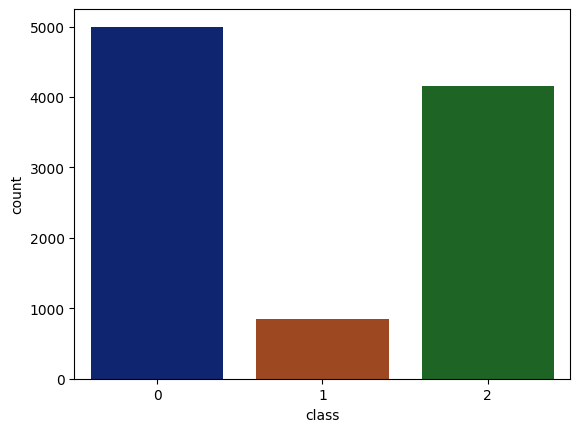

In [26]:
# here we are checking the number of labels of each class and plotting them on the map
sns.countplot(x=df['class'],palette='dark')

**Understanding relationship between the features of data**
There were 5 features provided namely-u,g,r,i,z.
To compare all of this data we will use a pairplot. This is typically used to understand the best set of features to explain the relationship between any two variables to test there dependecy,independency or co-dependency.

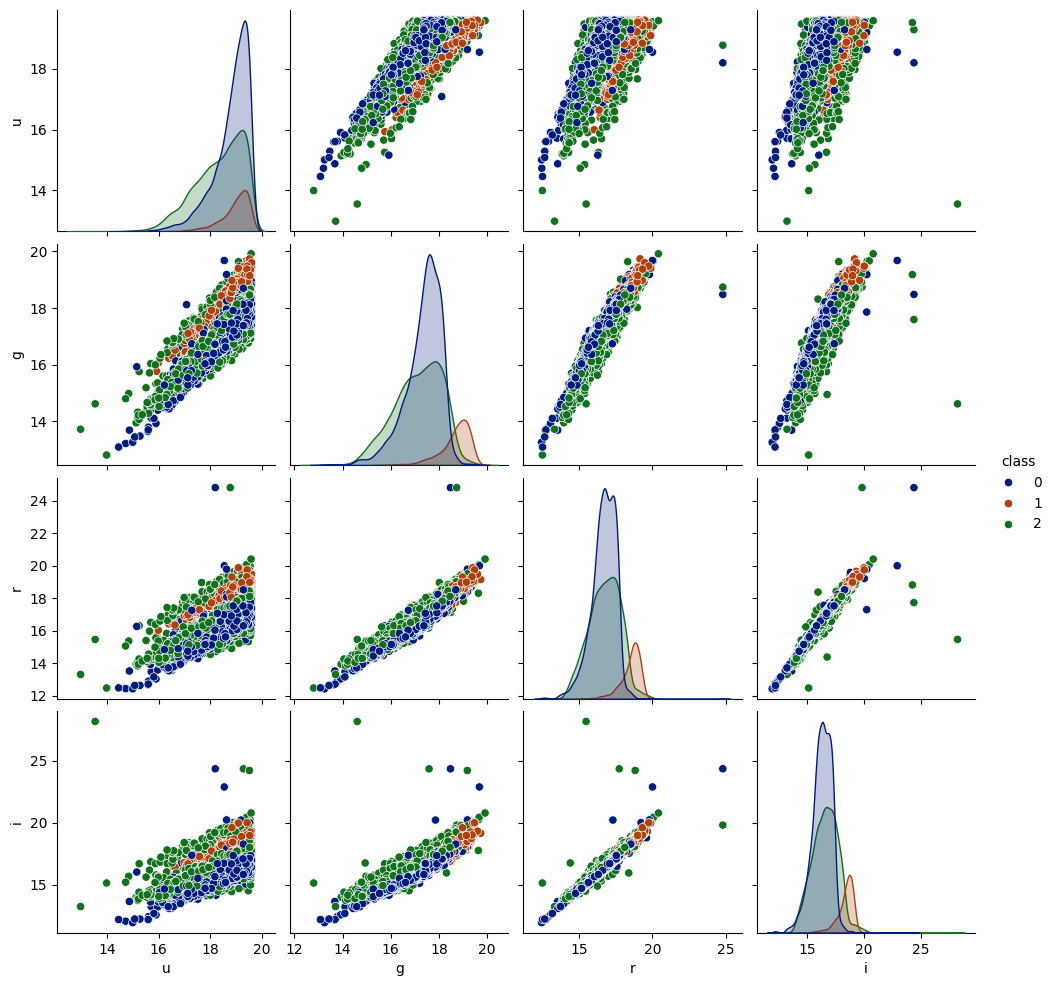

In [27]:
sns.pairplot(df[['u','g','r','i','class']],hue='class',palette='dark')

**Decision Tree Classifier**

In [28]:
# we will use decision trees ID3 Algorithim that uses top-down greedy approach to build a decision tree.
dt_classifier=DecisionTreeClassifier(max_leaf_nodes=15,max_depth=3)

**Logistic Regression**

In [29]:
# Linear classifier-Logistic Regression
lr_classifier=LogisticRegression()

**K Means Clustering**

In [30]:
# Using KMeans clustering to classify the class elements based on proximity.
knn_classifier=KNeighborsClassifier(n_neighbors=3)

**Fitting models to Dataset**

In [31]:
dt_classifier.fit(X_train,y_train)

lr_classifier.fit(X_train,y_train)

knn_classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [34]:
# getting predictions of the model
y_pred_dt=dt_classifier.predict(X_test)
y_pred_lr=lr_classifier.predict(X_test)
y_pred_knn=knn_classifier.predict(X_test)

In [38]:
# displaying outputs
print(y_pred_dt[:5],'\n',y_test[:5])
print('\n')
print(y_pred_lr[:5],'\n',y_test[:5])
print('\n')
print(y_pred_knn[:5],'\n',y_test[:5])

[2 0 2 2 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
Name: class, dtype: int64


[2 0 2 2 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
Name: class, dtype: int64


[2 0 2 2 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
Name: class, dtype: int64


**Classification Report**

In [40]:
from sklearn.metrics import classification_report
target_names=['0','1','2']

print('Decision Tree',classification_report(y_pred_dt,y_test,target_names=target_names)+'\n')
print('Logistic Regression',classification_report(y_pred_lr,y_test,target_names=target_names)+'\n')
print('KNN classifier',classification_report(y_pred_knn,y_test,target_names=target_names)+'\n')

Decision Tree               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1504
           1       0.94      0.98      0.96       255
           2       1.00      1.00      1.00      1241

    accuracy                           0.99      3000
   macro avg       0.98      0.99      0.98      3000
weighted avg       0.99      0.99      0.99      3000


Logistic Regression               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1469
           1       0.94      0.97      0.96       258
           2       0.99      0.96      0.98      1273

    accuracy                           0.98      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.98      0.98      0.98      3000


KNN classifier               precision    recall  f1-score   support

           0       0.94      0.89      0.91      1575
           1       0.88      0.97      0.92       240
           2       0.88 

From the above classification_report we can conclude that Decision Tree is the best model for classifying stars,galaxies and quasars in this dataset. Now we will see Decision tree by visualising it using scikit learn library.

In [41]:
df.columns

Index(['ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol', 'field',
       'class', 'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='object')

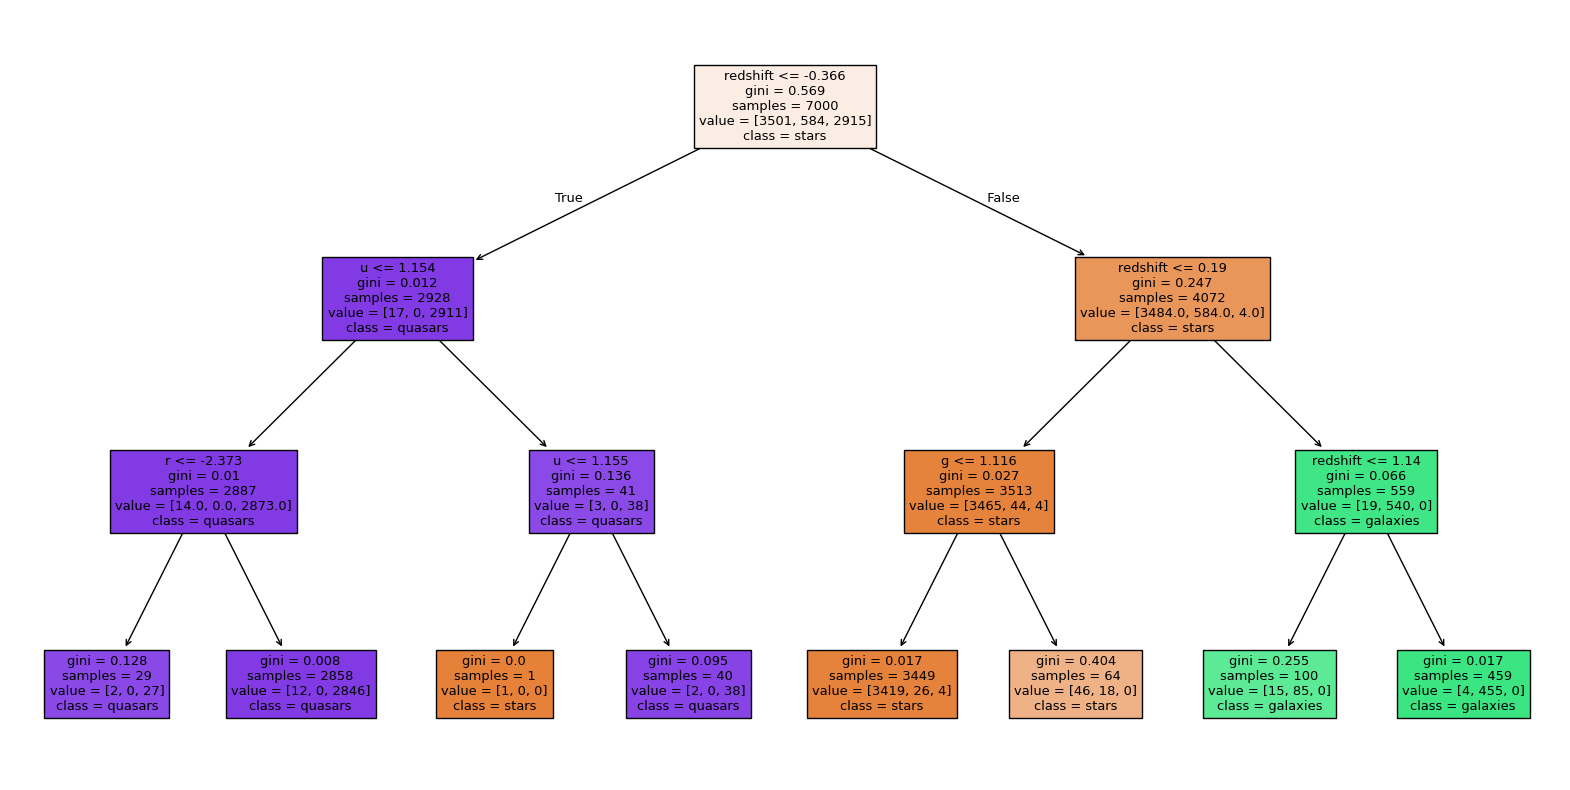

In [45]:
from sklearn import tree

plt.figure(figsize=(20,10))
feature_names=['ra','dec','u','g','r','i','z','run','rerun','camcol','field','redshift','plate','mjd','fiberid']
class_names=['stars','galaxies','quasars']
tree.plot_tree(dt_classifier,feature_names=feature_names,class_names=class_names,filled=True)
plt.show()